<a href="https://colab.research.google.com/github/allvaret/embeddings_similarity_recommendation/blob/main/notebooks/01_embedding_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Criação do Dataset e construção dos metadados
Para o dataset peguei parte das imagens do kaggle e adaptei a meu problema, por isso o drive como diretorio (adapte caso baixado diretamente)

### Resultado geral:
Recall@4 médio: 0.818  
Recall@4 mínimo: 0.250  
Recall@4 máximo: 1.250  
Anomalias (< 0.75): 25  
Anomalias (< 0.25): 8

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Chame a função para iniciar o processamento do dataset
# Certifique-se de que o diretório desejado existe e contém as subpastas com as imagens.
dataset_path = "/content/drive/MyDrive/Projects/similarity_recommendation/dataset/sneakers"

Criação dos metadados das imagens e "list_paths" que contem o caminho de todas as imagens

In [3]:
import os
import csv

def create_metadata(dataset_path):
  list_paths = []
  if not os.path.exists(dataset_path):
      print(f"Erro: Diretório do dataset de entrada '{dataset_path}' não encontrado.")
      return

  print(f"Iniciando processamento do dataset em '{dataset_path}'...")
  nome_arquivo_csv = "metadata.csv"
  colunas = ["id", "model_id", "category", "source", "path"]
  id_i = 0
  with open(nome_arquivo_csv, "w", newline="", encoding="utf-8") as arquivo:
    escritor = csv.DictWriter(arquivo, fieldnames=colunas, delimiter=";")

    # Escreve a primeira linha com o nome das colunas
    escritor.writeheader()

    # Iterar sobre as pastas de cada modelo
    for model_name in os.listdir(dataset_path):
      model_path = os.path.join(dataset_path, model_name)
      # Garantir que é um diretório
      if os.path.isdir(model_path):
        print(f"Processando imagens para o item: {model_name}")
        model_id = model_name.lower()

        # Iterar sobre as imagens dentro da pasta X
        for filename in os.listdir(model_path):
          # Verificar se é um arquivo de imagem
          if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(model_path, filename)
            print(f"  -> Processando imagem: {image_path}")
            list_paths.append(image_path)
            # inaugurar o json
            # dentro do try popular com as informacoes que ja tenho como: id, model_id, category (sneaker) source (kaggle), path
            try:
              linha = {
                  "id": id_i,
                  "model_id": model_id,
                  "category": "sneaker",
                  "source": "https://www.kaggle.com/datasets/nikolasgegenava/sneakers-classification",
                  "path": image_path
              }
              print(f"    ✓ ID: {id_i} | Model: {model_id}")
              escritor.writerow(linha)
              id_i += 1

            except Exception as e:
              print(f"Erro ao processar imagem: {image_path} - {e}")

  print(f"Arquivo '{nome_arquivo_csv}' gerado com sucesso!")
  return list_paths


In [4]:
list_paths = create_metadata(dataset_path)

Iniciando processamento do dataset em '/content/drive/MyDrive/Projects/similarity_recommendation/dataset/sneakers'...
Processando imagens para o item: adidas_forum_high
  -> Processando imagem: /content/drive/MyDrive/Projects/similarity_recommendation/dataset/sneakers/adidas_forum_high/0096.jpg
    ✓ ID: 0 | Model: adidas_forum_high
  -> Processando imagem: /content/drive/MyDrive/Projects/similarity_recommendation/dataset/sneakers/adidas_forum_high/0019.jpg
    ✓ ID: 1 | Model: adidas_forum_high
  -> Processando imagem: /content/drive/MyDrive/Projects/similarity_recommendation/dataset/sneakers/adidas_forum_high/0009.jpg
    ✓ ID: 2 | Model: adidas_forum_high
  -> Processando imagem: /content/drive/MyDrive/Projects/similarity_recommendation/dataset/sneakers/adidas_forum_high/0067.jpg
    ✓ ID: 3 | Model: adidas_forum_high
  -> Processando imagem: /content/drive/MyDrive/Projects/similarity_recommendation/dataset/sneakers/adidas_forum_high/0046.jpg
    ✓ ID: 4 | Model: adidas_forum_high
P

# Embeddings
Inicialmente com um pequeno conjunto

In [5]:
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 67.7 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.15.0
    Uninstalling transformers-5.15.0:
      Successfully uninstalled transformers-5.15.0


In [6]:
import torch
from transformers import AutoModel, AutoProcessor
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path
from PIL import Image


# Carregar modelo e processor
model = AutoModel.from_pretrained(
    "google/siglip2-base-patch16-224",
    device_map="auto",
    attn_implementation="sdpa"
)
processor = AutoProcessor.from_pretrained("google/siglip2-base-patch16-224")

# Colocar modelo em modo eval (importante!)
model.eval()

paths = [
    Path("/content/drive/MyDrive/Projects/similarity_recommendation/dataset/sneakers/nike_p6000/2.jpg"),
    Path("/content/drive/MyDrive/Projects/similarity_recommendation/dataset/sneakers/nike_air_max_1/0017.jpg"),
    Path("/content/drive/MyDrive/Projects/similarity_recommendation/dataset/sneakers/new_balance_550/0016.jpg")
]
images_ = [Image.open(p) for p in paths]

# PASSO 1: Processar imagens
inputs = processor(text=None,images=images_,  padding="max_length", max_length=64, return_tensors="pt").to(model.device)

# PASSO 2: Extrair embeddings (sem gradiente, mais rápido)
with torch.no_grad():
    outputs = model.get_image_features(**inputs) # Retorna "BaseModelOutputWithPooling"

image_embeddings = outputs.pooler_output  # shape: (batch_size, 768)

# PASSO 3: Normalizar (essencial pra cosine similarity ser eficiente)
image_features_normalized = image_embeddings / image_embeddings.norm(p=2, dim=-1, keepdim=True)

# PASSO 4: Calcular cosine similarity
# Entre imagem 0 e imagem 1
sim_01 = (image_features_normalized[0] @ image_features_normalized[1]).item()
print(f"Similaridade imagem 0 vs 1: {sim_01:.4f}")

# Entre todas as imagens (matriz completa)
similarity_matrix = cosine_similarity(
    image_features_normalized.cpu().numpy()
)
print(similarity_matrix)

config.json:   0%|          | 0.00/253 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.50GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/47.2k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 34.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Similaridade imagem 0 vs 1: 0.7480
[[1.0000002  0.7479814  0.652576  ]
 [0.7479814  0.99999994 0.725772  ]
 [0.652576   0.725772   1.0000002 ]]


# Processamento em lote
Evita carregar imagens na memória que não serão utilizadas naquele momento (ociosidade)

In [7]:
import torch
from PIL import Image

def process_images_in_batches(image_paths, model, processor, batch_size=32):
    """Processa imagens em lotes, convertendo todas para RGB."""
    all_embeddings = []

    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i + batch_size]

        # Carregar E converter para RGB
        batch_images = []
        for path in batch_paths:
            img = Image.open(path)
            # Converter para RGB (remove alpha, converte grayscale, etc)
            if img.mode != 'RGB':
                img = img.convert('RGB')
            batch_images.append(img)

        # Processar lote
        inputs = processor(images=batch_images, return_tensors="pt").to(model.device)

        with torch.no_grad():
            outputs = model.get_image_features(**inputs)
            embeddings = outputs.pooler_output
            embeddings_normalized = embeddings / embeddings.norm(p=2, dim=-1, keepdim=True)

        all_embeddings.append(embeddings_normalized.cpu())

        print(f"Processadas {min(i + batch_size, len(image_paths))}/{len(image_paths)} imagens")

    return torch.cat(all_embeddings, dim=0)

embeddings = process_images_in_batches(list_paths, model, processor, batch_size=32)

Processadas 32/129 imagens
Processadas 64/129 imagens
Processadas 96/129 imagens
Processadas 128/129 imagens
Processadas 129/129 imagens


# Plotando os itens mais similares

In [8]:
query_idx = 85 # tenis que gosto
query_emb = embeddings[query_idx]

similarities = embeddings @ query_emb  # (129,) - um score pra cada imagem

# Top-5 mais similares
top_k_similar = torch.topk(similarities, k=11)
indices_similar = top_k_similar.indices  # array([0, 45, 12, 89, 3])
values_similar = top_k_similar.values   # array([1.0, 0.95, 0.92, ...])

# Coletar as 5 imagens similares
similar_images = []
for idx in indices_similar:
    img = Image.open(list_paths[idx]).convert('RGB')
    similar_images.append(img)

# similar_images agora é uma lista com 5 PIL Images

# Mesma coisa para dissimilares
top_k_dissimilar = torch.topk(similarities, k=10, largest=False)
indices_dissimilar = top_k_dissimilar.indices
values_dissimilar = top_k_dissimilar.values

dissimilar_images = []
for idx in indices_dissimilar:
    img = Image.open(list_paths[idx]).convert('RGB')
    dissimilar_images.append(img)


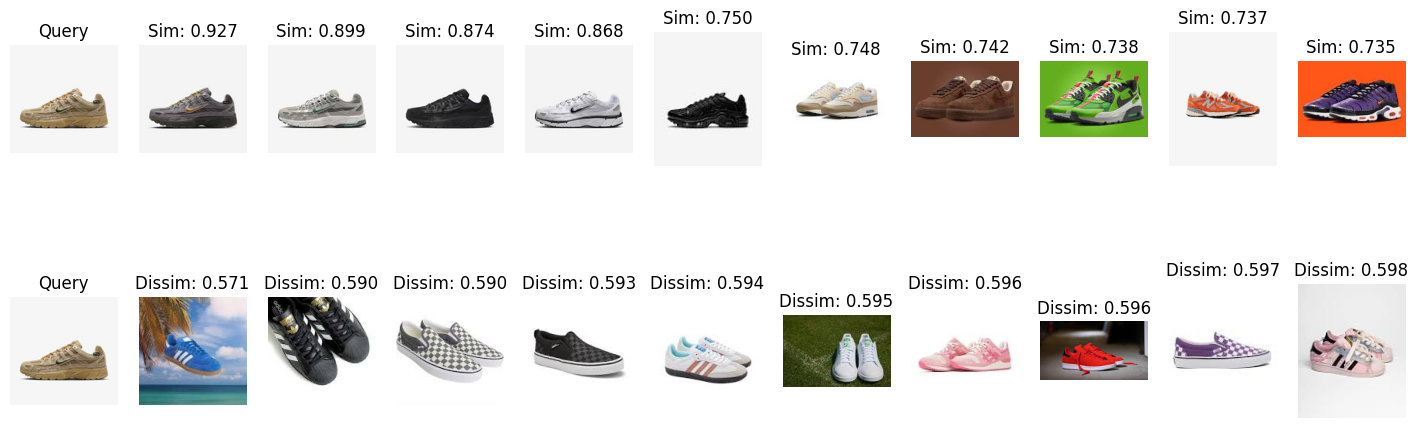

In [9]:
import matplotlib.pyplot as plt
import numpy as np


fig, axes = plt.subplots(2, 11, figsize=(18, 6))
# 2 linhas (similar e dissimilar)
# 6 colunas (1 query + 5 resultados)

# Linha 0: similar
axes[0, 0].imshow(Image.open(list_paths[query_idx]))
axes[0, 0].set_title("Query")
axes[0, 0].axis('off')  # Remove eixos

# Agora os 5 similares
for col, (idx, sim_value) in enumerate(zip(indices_similar[1:], values_similar[1:])):

    img = Image.open(list_paths[idx]).convert('RGB')
    axes[0, col+1].imshow(img)
    axes[0, col+1].set_title(f"Sim: {sim_value:.3f}")
    axes[0, col+1].axis('off')

# Linha 0: dissimilar
axes[1, 0].imshow(Image.open(list_paths[query_idx]))
axes[1, 0].set_title("Query")
axes[1, 0].axis('off')  # Remove eixos
# 5 disssimilares
for col, (idx, dissim_value) in enumerate(zip(indices_dissimilar, values_dissimilar)):
    img = Image.open(list_paths[idx]).convert('RGB')
    axes[1, col+1].imshow(img)
    axes[1, col+1].set_title(f"Dissim: {dissim_value:.3f}")
    axes[1, col+1].axis('off')



# Evaluation

In [10]:
def compute_topk_optimized(embeddings, k=5):
    """
    Calcula top-k similar E dissimilar com otimização a base de simetria de matriz — calcular só o triângulo superior e depois espelhar.
    Combinacoes = n * (n-1) / 2

    Evita redundância: se já calculou sim(i, j), não recalcula sim(j, i).

    Estratégia:
    1. Calcular só pra i >= j (triângulo superior/inferior)
    2. Preencher matriz completa espelhando resultados
    3. Extrair top-k de cada linha
    """
    n = embeddings.shape[0]

    # Matriz simetrica (N x N) com todas as similaridades
    similarity_matrix = torch.zeros(n, n)

    # PASSO 1: Calcular só a "metade" (evitar redundância)
    for i in range(n):
        # Comparar com imagens que vêm APÓS este índice (j > i)
        for j in range(i+1, n):
            sim = embeddings[i] @ embeddings[j]
            similarity_matrix[i, j] = sim
            similarity_matrix[j, i] = sim  # Espelhar (simetria)

    # Diagonal é 1 (cada imagem é 100% similar consigo mesma)
    for i in range(n):
        similarity_matrix[i, i] = 1.0

    # PASSO 2: Extrair top-k similar e dissimilar
    similar_indices = torch.zeros(n, k, dtype=torch.long)
    similar_values = torch.zeros(n, k)
    dissimilar_indices = torch.zeros(n, k, dtype=torch.long)
    dissimilar_values = torch.zeros(n, k)

    for i in range(n):
        sims = similarity_matrix[i]

        # TOP-K SIMILAR (excluir a diagonal, que é 1.0)
        top_k_sim = torch.topk(sims, k=k+1)
        mask_sim = top_k_sim.indices != i
        indices_sim = top_k_sim.indices[mask_sim][:k]
        values_sim = top_k_sim.values[mask_sim][:k]

        similar_indices[i] = indices_sim
        similar_values[i] = values_sim

        # TOP-K DISSIMILAR
        top_k_dissim = torch.topk(sims, k=k+1, largest=False)
        mask_dissim = top_k_dissim.indices != i
        indices_dissim = top_k_dissim.indices[mask_dissim][:k]
        values_dissim = top_k_dissim.values[mask_dissim][:k]

        dissimilar_indices[i] = indices_dissim
        dissimilar_values[i] = values_dissim

    return {
        'similarity_matrix': similarity_matrix,
        'similar_indices': similar_indices,
        'similar_values': similar_values,
        'dissimilar_indices': dissimilar_indices,
        'dissimilar_values': dissimilar_values
    }

# # Usar:
# results = compute_topk_optimized(embeddings, k=5)

# print(results)

Recall@4 médio: 0.818
Recall@4 mínimo: 0.250
Recall@4 máximo: 1.250
{57: {'query_model': 'nike_air_force_1_high', 'matches_model': 1, 'recall_4': 0.25, 'neighbors': [91, 89, 60, 93, 78]}, 59: {'query_model': 'nike_air_force_1_high', 'matches_model': 1, 'recall_4': 0.25, 'neighbors': [80, 91, 93, 88, 57]}, 60: {'query_model': 'nike_air_force_1_high', 'matches_model': 1, 'recall_4': 0.25, 'neighbors': [57, 78, 89, 93, 91]}, 61: {'query_model': 'nike_air_force_1_high', 'matches_model': 1, 'recall_4': 0.25, 'neighbors': [57, 77, 89, 93, 88]}, 65: {'query_model': 'new_balance_990', 'matches_model': 1, 'recall_4': 0.25, 'neighbors': [70, 64, 71, 67, 55]}, 74: {'query_model': 'new_balance_550', 'matches_model': 1, 'recall_4': 0.25, 'neighbors': [62, 71, 73, 56, 70]}, 93: {'query_model': 'nike_air_force_1_mid', 'matches_model': 1, 'recall_4': 0.25, 'neighbors': [91, 60, 57, 77, 78]}, 101: {'query_model': 'vans_sk8-hi', 'matches_model': 1, 'recall_4': 0.25, 'neighbors': [102, 121, 122, 123, 120

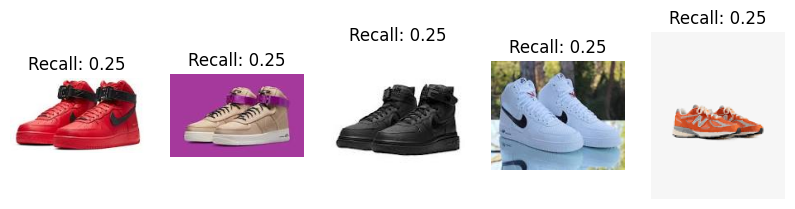

In [11]:
import pandas as pd
import numpy as np

# SETUP
metadata_df = pd.read_csv('/content/metadata.csv',sep=";")
metadata_dict = dict(zip(metadata_df['id'], metadata_df['model_id']))

results = compute_topk_optimized(embeddings, k=5)

# CALCULAR RECALL
recall_dict = {}

for query_idx in range(len(embeddings)):
    query_model = metadata_dict[query_idx]
    top_4_indices = results['similar_indices'][query_idx]

    matches_model = sum(1 for neighbor_idx in top_4_indices
                  if metadata_dict[neighbor_idx.item()] == query_model)

    recall_dict[query_idx] = {
        'query_model': query_model,
        'matches_model': matches_model,
        'recall_4': matches_model / 4,
        'neighbors': top_4_indices.tolist()
    }

# ESTATÍSTICAS
all_recalls = [recall_dict[i]['recall_4'] for i in range(len(embeddings))]
print(f"Recall@4 médio: {np.mean(all_recalls):.3f}")
print(f"Recall@4 mínimo: {np.min(all_recalls):.3f}")
print(f"Recall@4 máximo: {np.max(all_recalls):.3f}")



# ENCONTRAR ANOMALIAS
threshold = 0.75
anomalies = {idx: data for idx, data in recall_dict.items()
             if data['recall_4'] < threshold}
anomalies_25 = {idx: data for idx, data in anomalies.items()
              if data["recall_4"] <= 0.25}

print(anomalies_25)
print(f"Anomalias (< {threshold}): {len(anomalies)}")

fig, axes = plt.subplots(1, 5, figsize=(10,5))

for col, i  in enumerate(anomalies_25):
    img = Image.open(list_paths[i]).convert('RGB')
    axes[col].imshow(img)
    axes[col].set_title(f"Recall: {anomalies_25[i]['recall_4']}")
    axes[col].axis('off')
    if col == 4:
      break